# Additive + pairwise ground-truth demo

End-to-end pipeline:
1. Define a ground-truth function (additive motif + pairwise stem-loop + sigmoid nonlinearity)
2. Visualize GT coefficients
3. Generate a random mutagenesis library
4. Fit a surrogate of the same functional form (full pairwise)
5. Compare recovered coefficients against GT

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.ground_truth import GroundTruth, make_wt_seq
from src.library import generate_library, mutation_counts
from src.surrogate import fit_surrogate
from src import visualize as viz

## 1.  Ground-truth configuration

Stem-loop structure: arm1 = positions 8–13, arm2 = positions 36–41 (antiparallel).
Motif: 7 nt inside the loop (positions 17–23).

In [2]:
SEED = 42
L    = 50

stem_arm1 = list(range(8, 14))   # [8, 9, 10, 11, 12, 13]
stem_arm2 = list(range(36, 42))  # [36, 37, 38, 39, 40, 41]
# Antiparallel pairing: (8,41), (9,40), (10,39), (11,38), (12,37), (13,36)
stem_pairs = list(zip(stem_arm1, reversed(stem_arm2)))

motif_positions = list(range(17, 24))  # 7 nt motif in the loop

wt_seq = make_wt_seq(L, stem_pairs, seed=SEED)
print(f'WT ({L} nt): {wt_seq}')
print(f'Stem pairs:       {stem_pairs}')
print(f'Motif positions:  {motif_positions}')

WT (50 nt): ATGCCTAGCATTTAGTGATCGCATTGCTGCCAAGTATAAATGGCATCTGT
Stem pairs:       [(8, 41), (9, 40), (10, 39), (11, 38), (12, 37), (13, 36)]
Motif positions:  [17, 18, 19, 20, 21, 22, 23]


### Parameter intuition: sigmoid `a, b, c, d` and penalty strengths

Observed activity follows:
$$y(x) = a \cdot \sigma(b \cdot f_{\text{latent}}(x) + c) + d$$

**WT always has $f_{\text{latent}} = 0$** (every weight is defined relative to WT), so
$$y_{\text{WT}} = a \cdot \sigma(c) + d \quad \text{— independent of } b$$

This decoupling is the key insight:

| Param | Controls | Rule of thumb |
|-------|----------|---------------|
| `c` | WT operating point on the sigmoid | `c = logit((y_WT - d) / a)`. Raise `c` to push WT toward the top of the curve, giving more room to fall. |
| `b` | Sensitivity (slope amplifier for *mutants only*) | Larger `b` → each unit of disrupted f_latent translates to a bigger activity drop. Changing `b` does **not** move WT activity. |
| `a` | Dynamic range | Full swing from `d` to `a + d`. |
| `d` | Activity floor | Minimum activity for a fully broken sequence. |
| `stem_penalty_mu` | Cost per broken Watson-Crick pair (in f_latent units) | More negative → a single stem mutation is more catastrophic. |
| `motif_weight_mu` | Cost per wrong motif nucleotide | Tune relative to stem penalty to set which feature dominates. |

---

#### Three reference scenarios

**Scenario A — Gentle / recoverable**  
Library spreads broadly; both additive and pairwise terms are recoverable with moderate data.
```python
motif_weight_mu=-3.0, motif_weight_sigma=1.0,
stem_penalty_mu=-3.0, stem_penalty_sigma=1.0,
bg_mu=-0.05, bg_sigma=0.1,
a=1.0, b=0.125, c=0.405, d=0.0   # y_WT ≈ 0.60
# One stem mutation: sigmoid(0.125*(-3) + 0.405) = sigmoid(0.03) ≈ 0.51  (mild drop)
```

**Scenario B — Stem-dominated / fragile** *(current)*  
Stems are strong and the sigmoid is steep; a single broken base pair collapses activity.
Most of the library sits near zero, and the epistasis signal (compensatory pairs) is prominent.
```python
motif_weight_mu=-3.0, motif_weight_sigma=1.0,
stem_penalty_mu=-8.0, stem_penalty_sigma=0.5,
bg_mu=-0.5,  bg_sigma=1.0,
a=1.0, b=0.5, c=1.5, d=0.0        # y_WT ≈ 0.82
# One stem mutation: sigmoid(0.5*(-8) + 1.5) = sigmoid(-2.5) ≈ 0.076  (catastrophic)
```

**Scenario C — Motif-dominated**  
Motif mutations are highly deleterious; stems are present but weaker.
An additive surrogate will capture most of the variance; the pairwise signal is subtler.
```python
motif_weight_mu=-8.0, motif_weight_sigma=0.5,
stem_penalty_mu=-2.0, stem_penalty_sigma=1.0,
bg_mu=-0.1,  bg_sigma=0.3,
a=1.0, b=0.5, c=1.5, d=0.0        # y_WT ≈ 0.82
# One motif mutation: sigmoid(0.5*(-8) + 1.5) = sigmoid(-2.5) ≈ 0.076  (catastrophic)
# One stem  mutation: sigmoid(0.5*(-2) + 1.5) = sigmoid(0.5)  ≈ 0.62   (moderate)
```

In [3]:
gt = GroundTruth(
    L=L,
    wt_seq=wt_seq,
    stem_pairs=stem_pairs,
    motif_positions=motif_positions,
    # Motif: large negative penalties for wrong nucleotide
    motif_weight_mu=-3.0,
    motif_weight_sigma=1.0,
    # Stem: large negative penalties for non-canonical pairs
    stem_penalty_mu=-8.0,
    stem_penalty_sigma=1.0,
    # Background: small effects, centered slightly below zero
    bg_mu=-0.5,
    bg_sigma=1.0,
    # Sigmoid: WT at ~60% activity (c = logit(0.6) ≈ 0.405)
    # b=0.125 puts a fully broken stem at ~25% and two broken stems in the lower tail
    a=1.0, b=0.5, c=1.5, d=0.0,
    seed=SEED,
)
print(gt)

GroundTruth(L=50, motif=[17, 18, 19, 20, 21, 22, 23], stem_pairs=[(8, 41), (9, 40), (10, 39), (11, 38), (12, 37), (13, 36)], wt_activity=0.818)


In [ ]:
# --- Sanity checks ---
wt_oh = gt.wt_one_hot()
wt_idx = np.argmax(wt_oh, axis=1)

def break_all_stem(oh):
    oh = oh.copy()
    for i, j in gt.stem_pairs:
        oh[i] = [1,0,0,0]; oh[j] = [1,0,0,0]  # both -> A: non-canonical A-A pair
    return oh

def break_motif(oh):
    oh = oh.copy()
    for pos in gt.motif_positions:
        alt = (wt_idx[pos] + 1) % 4
        oh[pos] = np.eye(4)[alt]
    return oh

print(f'WT activity:                {gt.wt_activity():.3f}')
print(f'All stem pairs broken:      {gt(break_all_stem(wt_oh)):.3f}')
print(f'Full motif disrupted:       {gt(break_motif(wt_oh)):.3f}')

WT activity:                0.818  (target ~0.60)
All stem pairs broken:      0.000  (target ~0.25)
Full motif disrupted:       0.000


## 2.  Visualize GT coefficients

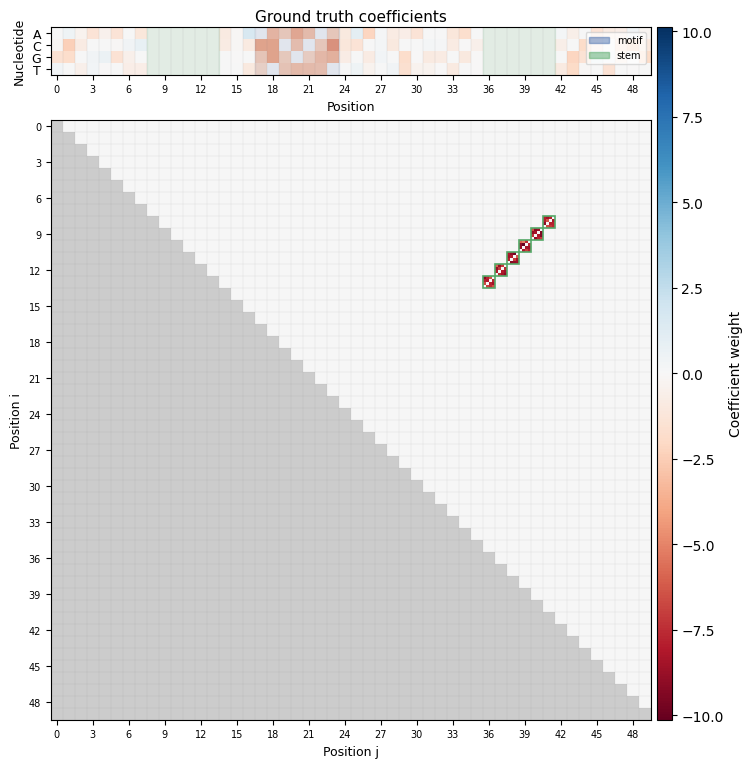

In [5]:
fig = viz.plot_coefficients(
    gt.alpha,
    gt.beta,
    L,
    stem_pairs=gt.stem_pairs,
    motif_positions=gt.motif_positions,
    title='Ground truth coefficients',
)
plt.show()

Top panel: 4×L additive weight matrix (blue shading = stem region, green = motif region).  
Bottom panel: 4L×4L pairwise weight matrix — only the six stem-pair blocks are non-zero; green rectangles mark them.

## 3.  Random mutagenesis library

In [6]:
NUM_SIM  = 20_000
MUT_RATE = 0.10   # Poisson(0.10 * 50) ≈ 5 mutations per sequence

x_mut, y_mut = generate_library(wt_oh, gt, NUM_SIM, MUT_RATE, seed=SEED)

mc = mutation_counts(x_mut, wt_oh)
print(f'Library: {x_mut.shape[0]:,} sequences')
print(f'Activity range: [{y_mut.min():.3f}, {y_mut.max():.3f}]')
print(f'Mut/seq: mean={mc.mean():.1f}  std={mc.std():.1f}')
print(f'Double mutants: {(mc == 2).sum():,}  ({100*(mc==2).mean():.1f}%)')

Mutagenesis:   0%|          | 0/19999 [00:00<?, ?it/s]

Mutagenesis: 100%|██████████| 19999/19999 [00:00<00:00, 41665.55it/s]


Library: 20,000 sequences
Activity range: [0.000, 0.934]
Mut/seq: mean=5.0  std=2.3
Double mutants: 1,685  (8.4%)


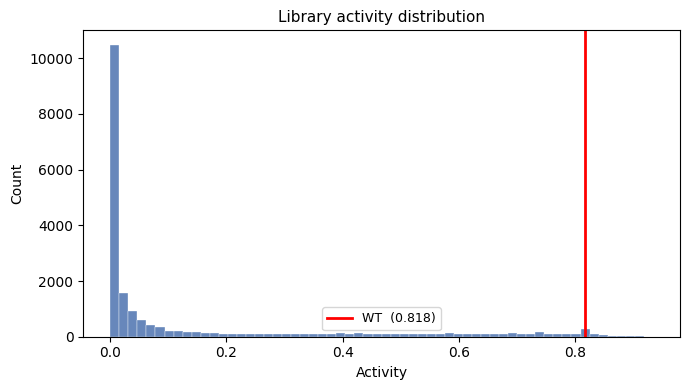

In [7]:
fig = viz.plot_library(y_mut, wt_y=gt.wt_activity())
plt.show()

## 4.  Fit surrogate (same functional form, full pairwise)

In [8]:
surrogate = fit_surrogate(
    x_mut, y_mut, L,
    epochs=500,
    lr=1e-3,
    batch_size=512,
    l1_lambda=0, # 1e-7,
    l2_lambda=0, #1e-6,
    device='cuda',   # 'cuda' if available
    verbose=True,
)
print('\nLearned sigmoid params:', surrogate.sigmoid_params())

Training surrogate:  10%|█         | 52/500 [00:02<00:19, 22.55it/s]

Epoch   50/500  loss=0.001847


Training surrogate:  21%|██        | 103/500 [00:04<00:17, 22.77it/s]

Epoch  100/500  loss=0.001623


Training surrogate:  31%|███       | 154/500 [00:07<00:15, 22.76it/s]

...

Epoch  400/500  loss=0.000015


Training surrogate:  91%|█████████ | 454/500 [00:20<00:02, 22.59it/s]

Epoch  450/500  loss=0.000011


Training surrogate: 100%|██████████| 500/500 [00:22<00:00, 22.38it/s]

Epoch  500/500  loss=0.000008

Learned sigmoid params: {'a': 0.9617173075675964, 'b': 1.0415606498718262, 'c': -1.8161182403564453, 'd': 0.00011500866094138473}


## 5.  Visualize learned coefficients

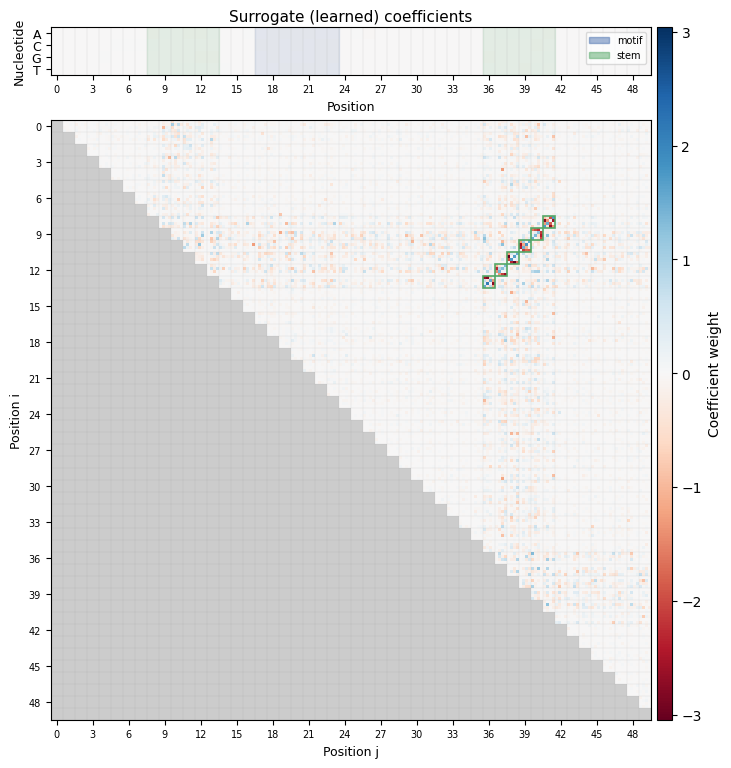

In [9]:
sur_alpha = surrogate.get_alpha()
sur_beta  = surrogate.get_beta_dict()

fig = viz.plot_coefficients(
    sur_alpha,
    sur_beta,
    L,
    stem_pairs=gt.stem_pairs,
    motif_positions=gt.motif_positions,
    title='Surrogate (learned) coefficients',
)
plt.show()

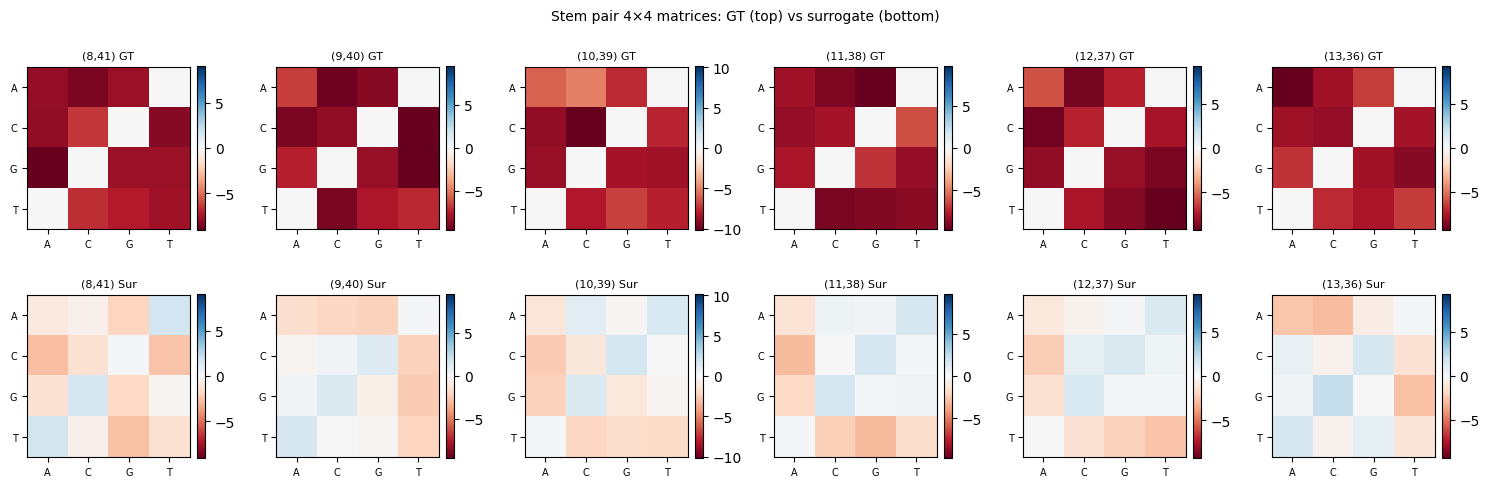

In [10]:
# Detailed comparison of GT vs surrogate 4x4 matrices for each stem pair
fig = viz.plot_stem_blocks(gt.beta, sur_beta, gt.stem_pairs)
plt.show()

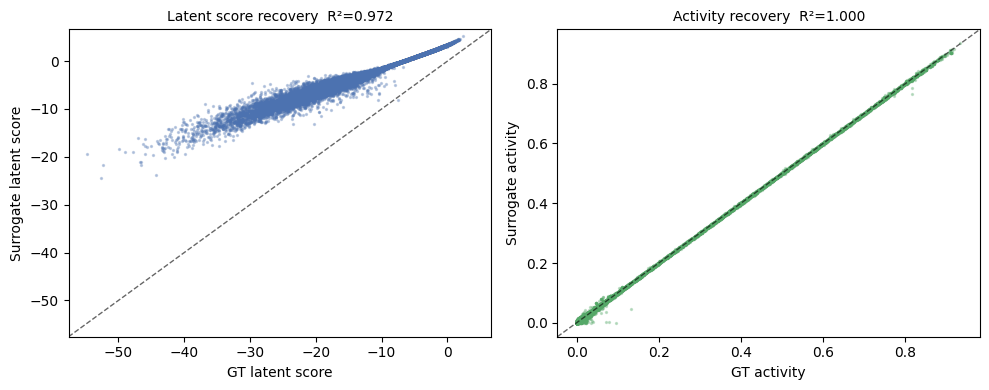

In [11]:
# Latent score and activity scatter: GT vs surrogate
fig = viz.plot_comparison(gt, surrogate, x_mut)
plt.show()

## 6.  Evaluate on a balanced dataset

In [12]:
from src.evaluate import make_additive_dataset, make_pairwise_dataset, make_ssm_deltas, predict_ssm

### 6a.  Category 1 — Additive evaluation

Random k-mutant sequences (k = 2, 3, 5) with mutations drawn **exclusively from non-stem positions**.
Because the GT has no pairwise interaction between non-stem positions, activity is a pure sum of additive terms.
A surrogate that correctly learned additive structure should track GT well at all k; systematic deviation at higher k reveals spurious pairwise interactions among non-stem sites.

In [13]:
x_add, y_add_gt, k_labels = make_additive_dataset(
    wt_oh, gt, ks=[2, 3, 5], n_per_k=500, seed=SEED
)
y_add_sur = surrogate.predict(x_add)

delta_ssm = make_ssm_deltas(wt_oh, gt)
y_add_ssm = predict_ssm(x_add, delta_ssm, gt.wt_activity())

for k in [2, 3, 5]:
    mask = k_labels == k
    r2_sur = float(np.corrcoef(y_add_gt[mask], y_add_sur[mask])[0, 1] ** 2)
    r2_ssm = float(np.corrcoef(y_add_gt[mask], y_add_ssm[mask])[0, 1] ** 2)
    print(f'k={k}  n={mask.sum()}  R² surrogate={r2_sur:.3f}  ssm={r2_ssm:.3f}')

k=2  n=500  R² surrogate=0.994  ssm=0.983
k=3  n=500  R² surrogate=0.985  ssm=0.969
k=5  n=500  R² surrogate=0.967  ssm=0.879


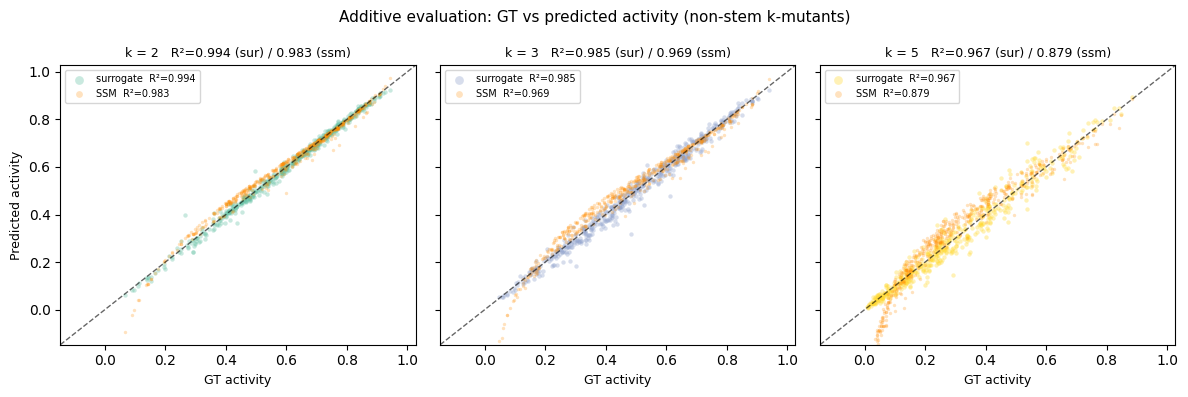

In [14]:
fig = viz.plot_additive_eval(y_add_gt, y_add_sur, k_labels, y_ssm=y_add_ssm)
plt.show()

### 6b.  Category 2 — Pairwise evaluation

For each of the 6 stem pairs, all 16 nucleotide combinations (4 × 4) are enumerated with every other position fixed at WT.
The 4×4 heatmaps show the full epistatic landscape: the surrogate should reproduce the GT pattern — low activity for non-canonical pairs and recovery for compensatory pairs.

In [15]:
x_pw, y_pw_gt, pair_labels, nuc_combos = make_pairwise_dataset(wt_oh, gt)
y_pw_sur = surrogate.predict(x_pw)
y_pw_ssm = predict_ssm(x_pw, delta_ssm, gt.wt_activity())

n_pairs = len(gt.stem_pairs)
print(f'Pairwise eval: {len(x_pw)} sequences  ({n_pairs} pairs x 16 combos)')
r2_pw = float(np.corrcoef(y_pw_gt, y_pw_sur)[0, 1] ** 2)
print(f'Surrogate R² (pairwise): {r2_pw:.3f}')
r2_ssm_pw = float(np.corrcoef(y_pw_gt, y_pw_ssm)[0, 1] ** 2)
print(f'SSM baseline R² (pairwise): {r2_ssm_pw:.3f}')

Pairwise eval: 96 sequences  (6 pairs x 16 combos)
Surrogate R² (pairwise): 0.585
SSM baseline R² (pairwise): 0.000


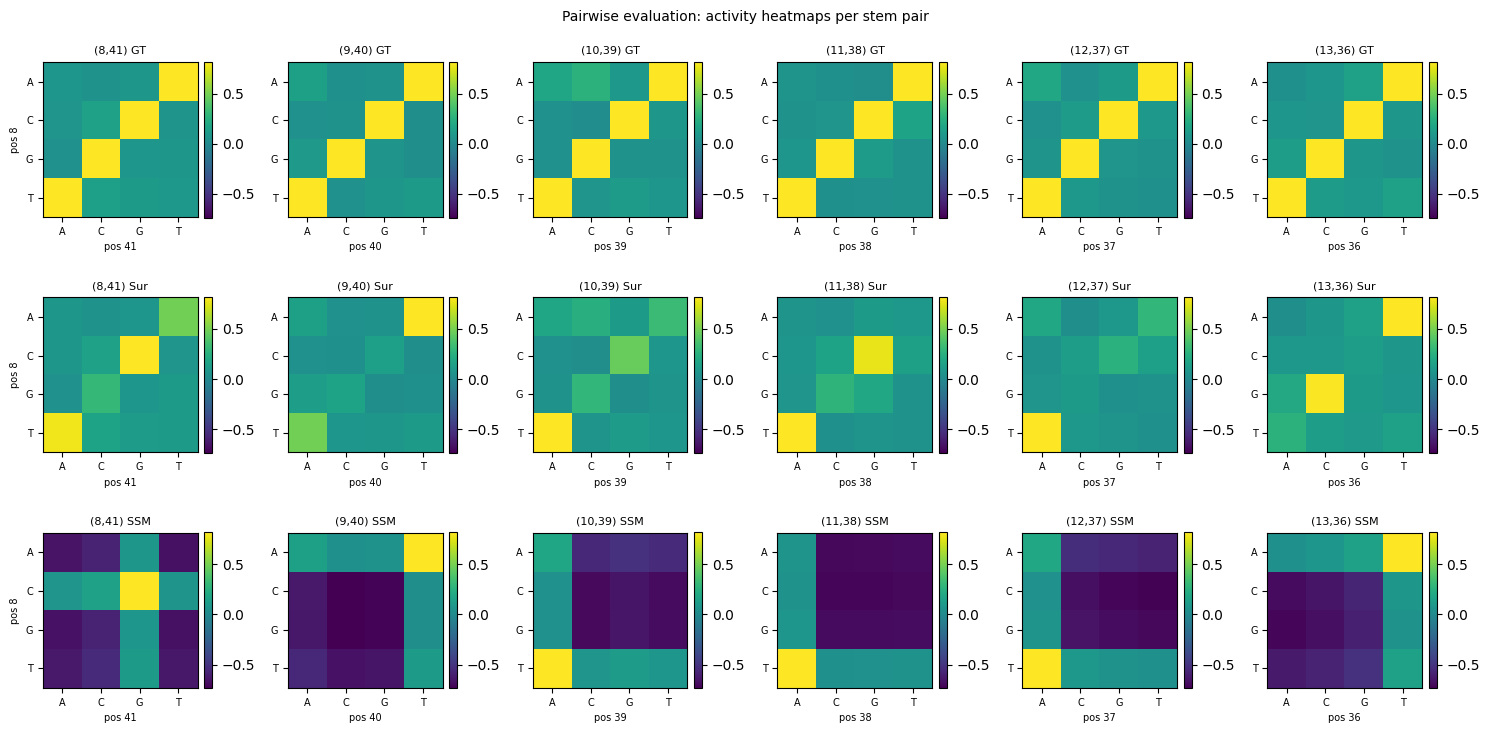

In [16]:
fig = viz.plot_pairwise_eval(y_pw_gt, y_pw_sur, pair_labels, nuc_combos, gt.stem_pairs, y_ssm=y_pw_ssm)
plt.show()